# Train Japanese CNN from etl8b dataset

In [2]:
import torch
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from torch import nn
import h5py
from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import sys
from jis_x_0208 import JIS0208
from sklearn.preprocessing import LabelEncoder

In [3]:
imgs, labels = None, None

with h5py.File("/kaggle/input/etl8b-uncleaned/ETL8B2C1.h5", 'r') as f:
    imgs = f['images'][:]
    labels= f['labels'][:]

labels = [label.decode('utf-8') for label in labels]

# print(f"type of labels is {type(labels)}")
print(len(labels))

12000


In [4]:
imgs[0].shape

(63, 64)

## Preparing Dataset
converting dataset into pytorch dataset, create data augmentation function

### Data Augmentation
To increase the variety of data a model sees without actually increasing the dataset size, we perform operations such as rescaling and rotating each image multiple times. This is performed in the dataloader so that we dont need to store the augmented data.

In [40]:
import torchvision.transforms.v2.functional as F
import random
from PIL import Image

def random_rotate_shrink(image: Image.Image,
                         degrees: tuple = (-10, 10),
                         scale_range: tuple = (0.9, 1.0),
                         interpolation=F.InterpolationMode.BILINEAR,
                         fill=0) -> Image.Image:
    """
    Apply a random rotation and shrink (scaling) to an image.
    
    Args:
        image (PIL.Image): Input image.
        degrees (tuple): Range of degrees for rotation.
        scale_range (tuple): Range for scaling.
        interpolation: Interpolation method.g
        fill (int or tuple): Fill color for empty space.
    
    Returns:
        PIL.Image: Transformed image.
    """
    width = len(image[0])
    height = len(image[0])
    angle = random.uniform(*degrees)
    scale = random.uniform(*scale_range)
    center = (width // 2, height // 2)

    return F.affine(
        image,
        angle=angle,
        translate=[0, 0],
        scale=scale,
        shear=[0.0, 0.0],
        interpolation=interpolation,
        center=center,
        fill=fill
    )


In [41]:
class ETL8B(torch.utils.data.Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.labels[idx]

new_imgs = []
for image in imgs:
    h, w = image.shape
    if h == 63:
        pad = np.zeros((1, w), dtype=image.dtype)
        image = np.vstack((image, pad))

    image = torch.from_numpy(image).unsqueeze(0).float()
    new_imgs.append(image)

le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

dataset = ETL8B(new_imgs, encoded_labels, transform=random_rotate_shrink)

In [42]:
import pickle
l = le.inverse_transform(range(0,75)).astype(str).tolist()

with open("lookup.pkl", "wb") as fp:   #Pickling
    pickle.dump(l, fp)


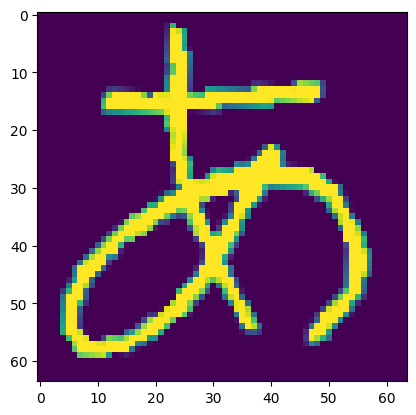

In [43]:
plt.imshow(dataset[100][0].numpy()[0])
plt.show()

In [44]:
type(imgs)

numpy.ndarray

### Model Architecture

Convolutional feature extractor:
- Two convolutional blocks, each with:
- Two Conv2D layers, extract spatial features
- BatchNorm, stabilize training
- ReLU, non-linearity
- Dropout (0.5), prevent overfitting
- MaxPooling after each block, reduce spatial dimensions
Model Architecture

Fully connected classifier:
- Flatten the feature maps
- Pass through a linear layer to map features to 256 neurons
- BatchNorm + ReLU + Dropout
- Output feature vector ready for classification

In [45]:
class Kanas_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            # First conv block (2 conv layers)
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.MaxPool2d(kernel_size=2, stride=2),  # Optional pooling between blocks

            # Second conv block (2 conv layers)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully connected layer (FC-256)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),  # Adjust 7x7 based on input size (e.g., 28x28 input)
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
            
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
    

## Train Model

In [55]:
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = Kanas_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
model.to(device)

Using device: cuda


Kanas_CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.5, inplace=False)
    (13): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Dropout(p=0.5, inplace=Fals

In [58]:
for epoch in range(20):
    for imgs_batch, labels_batch in dataloader:
        imgs_batch = imgs_batch.float().to(device)
        labels_batch = labels_batch.long().to(device)
        
        preds = model(imgs_batch)
        loss = criterion(preds,labels_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Loss after epoch {epoch + 1}: {loss.item():.4f}")

Loss after epoch 1: 0.4143
Loss after epoch 2: 0.0960
Loss after epoch 3: 0.1741
Loss after epoch 4: 0.2178
Loss after epoch 5: 0.2441
Loss after epoch 6: 0.0412
Loss after epoch 7: 0.0579
Loss after epoch 8: 0.0722
Loss after epoch 9: 0.0674
Loss after epoch 10: 0.0733
Loss after epoch 11: 0.0450
Loss after epoch 12: 0.0295
Loss after epoch 13: 0.0042
Loss after epoch 14: 0.0379
Loss after epoch 15: 0.0221
Loss after epoch 16: 0.0235
Loss after epoch 17: 0.0022
Loss after epoch 18: 0.0625
Loss after epoch 19: 0.0065
Loss after epoch 20: 0.0386


In [59]:
model.eval()
with torch.no_grad():
    print(model(dataset.data[3500].to(torch.float32).unsqueeze(0).to(device)).argmax())

tensor(21, device='cuda:0')


## Evaluate Model

In [60]:
def calculate_accuracy(model, dataloader, device, label_encoder=None):
    model.eval()
    model.to(device)
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.float().to(device)
            labels = labels.to(device)
            
            logits = model(imgs)  # shape: [batch_size, num_classes]
            preds = torch.argmax(logits, dim=1)
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    accuracy = correct / total
    print(f"Accuracy: {accuracy * 100:.2f}%")
    
    if label_encoder is not None:
        # optional: return predicted labels for inspection
        return label_encoder.inverse_transform(preds.cpu())
    
    return accuracy

calculate_accuracy(model, dataloader, "cuda", le)

Accuracy: 98.75%


array(['へ', 'ぜ', 'ぐ', 'く', 'ゅ', 'き', 'む', 'な', 'づ', 'る', 'も', 'ぽ', 'う',
       'ば', 'け', 'で', 'る', 'つ', 'ぽ', 'つ', 'は', 'ぐ', 'ぢ', 'ほ', 'ざ', 'ぜ',
       'わ', 'み', 'ば', 'げ', 'げ', 'ご'], dtype='<U1')

## Save Model

In [61]:
torch.save(model.state_dict(), "kanas_cnn_weights.pth")